## Library

In [1]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: data_release/
  inflating: __MACOSX/._data_release  
  inflating: data_release/.Rhistory  
  inflating: __MACOSX/data_release/._.Rhistory  
  inflating: data_release/belief_data.csv  
  inflating: __MACOSX/data_release/._belief_data.csv  
  inflating: data_release/ratings_for_additional_users.csv  
  inflating: __MACOSX/data_release/._ratings_for_additional_users.csv  
  inflating: data_release/movie_elicitation_set.csv  
  inflating: __MACOSX/data_release/._movie_elicitation_set.csv  
  inflating: data_release/user_recommendation_history.csv  
  inflating: __MACOSX/data_release/._user_recommendation_history.csv  
  inflating: data_release/README.txt  
  inflating: __MACOSX/data_release/._README.txt  
  inflating: data_release/movies.csv  
  inflating: __MACOSX/data_release/._movies.csv  
  inflating: data_release/user_rating_history.csv  
  inflating: __MACOSX/data_release/._user_rating_history.csv  


In [52]:
!pip install tensorflow

In [53]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from zipfile import ZipFile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

## Data Description
### movies.csv
1. movieId: ID film
2. title: Judul film
3. genres: Genre film

### user_rating_history.csv
1. userId: ID pengguna
2. movieId: ID film
3. rating: Skor rating (0.5 - 5.0, kelipatan 0.5)
4. timestamp: Waktu rating diberikan (dalam format UNIX timestamp)

## Extract Data

In [54]:
df_movie = pd.read_csv('data_release/movies.csv')

In [55]:
df_user = pd.read_csv('data_release/user_rating_history.csv')

In [56]:
df_movie

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
105066,262135,Becoming Cousteau (2021),Documentary
105067,262137,Death Goes to School (1953),Mystery
105068,262139,Street of Shadows (1953),Crime|Drama
105069,262141,The Accusation (2021),Drama


In [57]:
df_user

,userId,movieId,rating,tstamp
0,42170,1,4.0,1998-06-18 16:31:37
1,42170,7,4.0,1998-06-18 16:31:37
2,42170,17,4.0,1998-06-18 16:31:37
3,42170,24,2.0,1997-11-07 13:41:17
4,42170,36,2.0,1997-11-07 13:27:51
...,...,...,...,...
2046119,403333,93838,2.0,2024-05-05 21:38:27
2046120,396424,179817,4.0,2024-05-05 21:40:11
2046121,403333,196567,5.0,2024-05-05 21:40:38
2046122,311568,113741,3.0,2024-05-05 21:45:32


## Assessing Data

### Data Movie

In [58]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105071 entries, 0 to 105070
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   movieId  105071 non-null  int64 
 1   title    105071 non-null  object
 2   genres   104629 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.4+ MB


In [59]:
df_movie.duplicated().sum()

np.int64(0)

Tidak ada data duplikat

In [60]:
df_movie.isna().sum()

,0
movieId,0
title,0
genres,442


In [61]:
df_movie.isnull().sum()

,0
movieId,0
title,0
genres,442


Memiliki 442 missing value pada kolom genres

In [62]:
(df_movie['genres'] == "|").sum()

np.int64(0)

### Data User Rating

In [63]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2046124 entries, 0 to 2046123
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
 3   tstamp   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 62.4+ MB


In [64]:
df_user.duplicated().sum()

np.int64(41815)

Terdapat banyak data duplikat pada data ini

In [65]:
df_user.isna().sum()

,0
userId,0
movieId,0
rating,36521
tstamp,0


Terdapat banyak missing value pada kolom rating

## Data Preparation



### Data Prep Movie

In [66]:
df_movie.dropna(inplace=True)

Menghapus missing value pada data (dropna())

In [67]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104629 entries, 0 to 105070
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   movieId  104629 non-null  int64 
 1   title    104629 non-null  object
 2   genres   104629 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.2+ MB


In [68]:
df_movie['genres'] = df_movie['genres'].str.replace('|',' ')

Menghilangkan simbol "|" pada kolom genres sehingga setiap genre dipisah dengan menggunakan spasi saja.

In [69]:
df_movie

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
105066,262135,Becoming Cousteau (2021),Documentary
105067,262137,Death Goes to School (1953),Mystery
105068,262139,Street of Shadows (1953),Crime Drama
105069,262141,The Accusation (2021),Drama


Pada tahap ini dilakukan drop pada missing value dan menghilangkan simbol "|" dari genres agar dipisah menggunakan spasi.

In [70]:
tfid = TfidfVectorizer()
tfid.fit(df_movie['genres'])
tfid.get_feature_names_out()

array(['action', 'adventure', 'animation', 'children', 'comedy', 'crime',
       'documentary', 'drama', 'fantasy', 'fi', 'film', 'genres',
       'horror', 'imax', 'listed', 'musical', 'mystery', 'no', 'noir',
       'romance', 'sci', 'thriller', 'war', 'western'], dtype=object)

In [71]:
tf_matrix = tfid.fit_transform(df_movie['genres'])

In [72]:
tf_matrix.shape

(104629, 24)

In [73]:
tf_matrix.todense()

matrix([[0.        , 0.45802205, 0.4796122 , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.55147092, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]])

Data yang sudah bersih diproses menggunakan TfidVectorizer. TfidVectorizer mengubah teks menjadi representasi numerik yang bertujuan agar model dapat mengukur kemiripan antar film berdasarkan genre. Matrix yang didapat setelah diproses dijadikan dense agar dapat ditampilkan dalam bentuk tabel.

In [74]:
pd.DataFrame(
    tf_matrix.todense(),
    columns=tfid.get_feature_names_out(),
    index=df_movie.title
).sample(24, axis=1).sample(10, axis=0)

,listed,mystery,fi,noir,comedy,animation,film,war,action,genres,...,musical,children,imax,documentary,drama,romance,thriller,adventure,sci,crime
title,,,,,,,,,,,,,,,,,,,,,
The Inheritance (1976),0.00000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Citizen Lane (2018),0.00000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Resident Evil: Retribution (2012),0.00000,0.0,0.38228,0.0,0.000000,0.0,0.0,0.0,0.313955,0.00000,...,0.0,0.000000,0.710594,0.0,0.000000,0.000000,0.000000,0.000000,0.38228,0.000000
My Sister's Kids in Africa (2013),0.00000,0.0,0.00000,0.0,0.392291,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.665873,0.000000,0.0,0.000000,0.000000,0.000000,0.634603,0.00000,0.000000
London Nahi Jaunga (2022),0.00000,0.0,0.00000,0.0,0.462188,0.0,0.0,0.0,0.631889,0.00000,...,0.0,0.000000,0.000000,0.0,0.000000,0.622172,0.000000,0.000000,0.00000,0.000000
O Último Virgem (2016),0.00000,0.0,0.00000,0.0,0.596327,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.000000,0.000000,0.0,0.000000,0.802742,0.000000,0.000000,0.00000,0.000000
Zion (2018),0.00000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Nitro (2006),0.00000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.00000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
"Verlorene, Der (Lost One, The) (1951)",0.00000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,...,0.0,0.000000,0.000000,0.0,0.387582,0.000000,0.597068,0.000000,0.00000,0.702346


### Data Prep User Rating

In [75]:
df_user.dropna(inplace=True)

Menghapus missing value pada data (dropna())

In [76]:
df_user.drop_duplicates(inplace=True)

Menghapus data duplikat (drop_duplicates())

In [77]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1967822 entries, 0 to 2046123
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
 3   tstamp   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 75.1+ MB


## EDA

In [78]:
eda_df = df_movie.merge(df_user, on='movieId', how='left')

In [79]:
eda_df.dropna(inplace=True)

<ipython-input-80-67aaaa13c159>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette=colors)


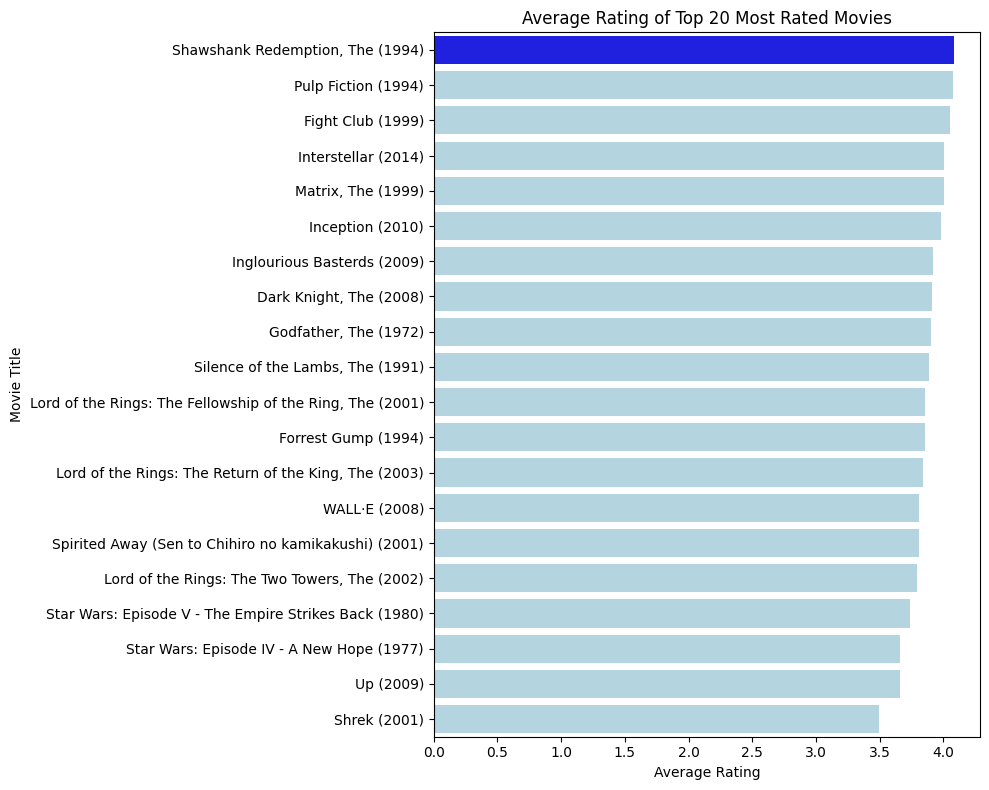

In [80]:
top_movies_by_rating_count = eda_df['title'].value_counts().head(20).index
top_rated_movies = eda_df[eda_df['title'].isin(top_movies_by_rating_count)]


avg_ratings = top_rated_movies.groupby('title')['rating'].mean().sort_values(ascending=False)

colors = ['blue' if count == avg_ratings.max() else 'lightblue' for count in avg_ratings]

plt.figure(figsize=(10, 8))
sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette=colors)
plt.title("Average Rating of Top 20 Most Rated Movies")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()

Gambar di atas merupakan bar chart mengenai top 20 film dengan rating terbanyak. Film yang memiliki rating terbanyak adalah The Shawshank Redemption. Dari top 20 film ini, rata-rata film memiliki rating di atas 3.5.

In [81]:
eda_df['genres'] = eda_df['genres'].str.split()
eda_df_exploded = eda_df.explode('genres')

<ipython-input-82-006011988fb7>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_avg_ratings.values, y=genre_avg_ratings.index, palette=colors)


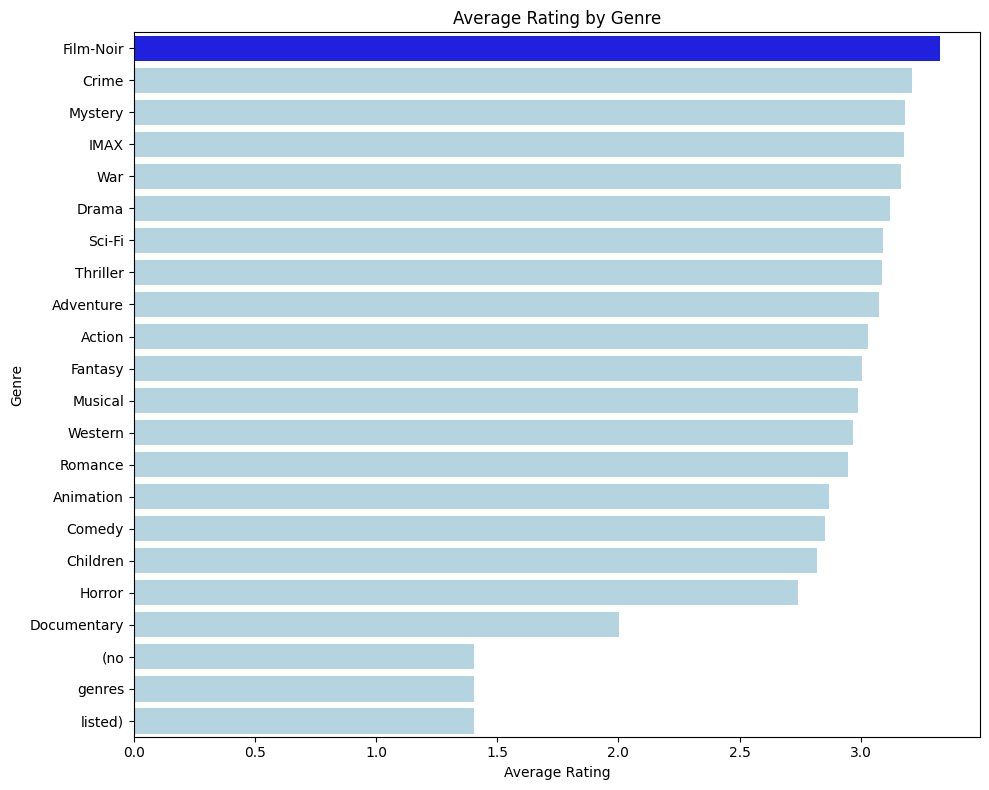

In [82]:
genre_avg_ratings = eda_df_exploded.groupby('genres')['rating'].mean().sort_values(ascending=False)

top_rating = genre_avg_ratings.max()
colors = ['blue' if rating == top_rating else 'lightblue' for rating in genre_avg_ratings]

plt.figure(figsize=(10, 8))
sns.barplot(x=genre_avg_ratings.values, y=genre_avg_ratings.index, palette=colors)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Gambar di atas merupakan bar chart mengenai rata-rata rating setiap genre. Genre yang paling banyak diminati orang adalah film dengan genre Film-Noir.

## Modeling (Content-based filtering)

In [83]:
from sklearn.metrics.pairwise import linear_kernel

sim = linear_kernel(tf_matrix, tf_matrix)

Membangun model menggunakan linear kernel

In [84]:
sim_df = pd.DataFrame(sim, index=df_movie['title'], columns=df_movie['title'])

print('Shape:', sim_df.shape)

sim_df.index = sim_df.index.str.strip()

sim_df.sample(5, axis=1).sample(10, axis=0)


Shape: (104629, 104629)


title,Scenery to Remember (2008),Ring of Fire (1961),I Don't Know Jack (2002),Renfroe's White Christmas (1997),Hunger (1966)
title,,,,,
45 R.P.M. (2008),0.358167,0.351957,0.0,0.0,1.000000
Close to Leo (Tout contre Léo) (2002),0.358167,0.351957,0.0,0.0,1.000000
"Yes Men Are Revolting, The (2014)",0.000000,0.000000,1.0,0.0,0.000000
Malibu High (1979),0.000000,0.531323,0.0,0.0,0.000000
Force majeure (1989),0.000000,0.000000,0.0,1.0,0.000000
"Misérables, Les (2000)",0.681807,0.184890,0.0,0.0,0.525320
The Grand Son (2018),0.173050,0.728458,0.0,0.0,0.483154
Harper Valley P.T.A. (1978),0.000000,0.000000,0.0,0.0,0.000000
The Crew (2016),0.000000,0.000000,0.0,0.0,0.000000


In [85]:
def movie_rec(movie_name, similarity_data=sim_df, items=df_movie[['title', 'genres']], k=10):
    index = similarity_data.loc[:,movie_name].to_numpy().argpartition(range(-1, -k, -1))
    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    closest = closest.drop(movie_name, errors='ignore')
    result = pd.DataFrame(closest).rename(columns={0: 'title'})
    result['similarity'] = result['title'].apply(lambda x: similarity_data.at[x, movie_name])
    result = result.merge(items, on='title').sort_values(by='similarity', ascending=False).reset_index(drop=True)
    return result.head(k)

Fungsi movie_rec() untuk mengambil k film paling mirip dengan film input

In [86]:
movie_rec('Tokyo Girls (2000)')

,title,similarity,genres
0,I Called Him Morgan (2016),1.0,Documentary
1,Elián,1.0,Documentary
2,China Not China (2018),1.0,Documentary
3,What the Health (2017),1.0,Documentary
4,Bobbi Jene (2017),1.0,Documentary
5,Canary (2023),1.0,Documentary
6,Give Me Future: Major Lazer in Cuba (2017),1.0,Documentary
7,OLIVIA RODRIGO: driving home 2 u (a SOUR film)...,1.0,Documentary
8,Joshua: Teenager vs. Superpower (2017),1.0,Documentary
9,Echo in the Canyon (2019),1.0,Documentary


In [87]:
df_movie[df_movie['title'] == 'Tokyo Girls (2000)']['genres']

,genres
100325,Documentary


Dari fungsi yang sudah didefinisikan sebelumnya bahwa nilai K adalah 10, maka ditampilkan 10 film yang mirip dengan film yang dicari (Tokyo Girls (2000)). Berikut merupakan lima film yang mirip dengan Tokyo Girls (2000):
1. I Called Him Morgan (2016) : Documentary
2. Elián : Documentary
3. China Not China (2018) : Documentary
4. What the Health (2017) : Documentary
5. Bobbi Jene (2017)  : Documentary
6. Canary (2023) : Documentary
7. Give Me Future: Major Lazer in Cuba (2017) : Documentary
8. OLIVIA RODRIGO: driving home 2 u (a SOUR film) (2022) : Documentary
9. Joshua: Teenager vs. Superpower (2017) : Documentary
10. Echo in the Canyon (2019) : Documentary

# Part Collaborative Filtering

## Data Preparation

In [88]:
merge_df = df_user.merge(df_movie, on='movieId', how='left')

Menggabungkan df_use sebagai left table dan df_movie menggunakan Left Join berdasarkan movieId

In [89]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967822 entries, 0 to 1967821
Data columns (total 6 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
 3   tstamp   object 
 4   title    object 
 5   genres   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 90.1+ MB


In [90]:
merge_df.isna().sum()

,0
userId,0
movieId,0
rating,0
tstamp,0
title,1791
genres,1791


In [91]:
merge_df.dropna(inplace=True)

Menghapus missing value pada data(dropna())

In [92]:
merge_df

,userId,movieId,rating,tstamp,title,genres
0,42170,1,4.0,1998-06-18 16:31:37,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,42170,7,4.0,1998-06-18 16:31:37,Sabrina (1995),Comedy Romance
2,42170,17,4.0,1998-06-18 16:31:37,Sense and Sensibility (1995),Drama Romance
3,42170,24,2.0,1997-11-07 13:41:17,Powder (1995),Drama Sci-Fi
4,42170,36,2.0,1997-11-07 13:27:51,Dead Man Walking (1995),Crime Drama
...,...,...,...,...,...,...
1967817,403333,93838,2.0,2024-05-05 21:38:27,The Raid: Redemption (2011),Action Crime
1967818,396424,179817,4.0,2024-05-05 21:40:11,Darkest Hour (2017),Drama War
1967819,403333,196567,5.0,2024-05-05 21:40:38,Wild Rose (2019),Comedy Drama
1967820,311568,113741,3.0,2024-05-05 21:45:32,Coherence (2013),Drama Mystery Sci-Fi Thriller


In [93]:
user_ids   = merge_df["userId"].unique().tolist()
movie_ids  = merge_df["movieId"].unique().tolist()

user_to_user_encoded  = {x: i for i, x in enumerate(user_ids)}
movie_to_movie_encoded = {x: i for i, x in enumerate(movie_ids)}

In [95]:
merge_df['user'] = merge_df['userId'].map(user_to_user_encoded)
merge_df['movie'] = merge_df['movieId'].map(movie_to_movie_encoded)

Mengubah userId dan movieId menjadi angka integer

In [96]:
n_user = len(user_to_user_encoded)
n_movie = len(movie_to_movie_encoded)

In [97]:
min_rating, max_rating = merge_df["rating"].min(), merge_df["rating"].max()
merge_df["rating_norm"] = (merge_df["rating"] - min_rating) / (max_rating - min_rating)

Menormalkan rating menjadi rentang 0-1

In [98]:
X = merge_df[["user", "movie"]].values
y = merge_df["rating_norm"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Menyusun pasangan fitur user dan movie dalam bentuk array dan label rating_norm. Membagi data menjadi data latih dan data validasi dengan rasio 80:20

## Modeling

In [104]:
class RecommenderNet(tf.keras.Model):
  def __init__(self, num_users, num_movies, embedding_size, **kwargs):
    super(RecommenderNet, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_movies = num_movies
    self.embedding_size = embedding_size
    self.user_embedding = layers.Embedding(
        num_users,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-3)
    )
    self.user_bias = layers.Embedding(num_users, 1)
    self.movies_embedding = layers.Embedding(
        num_movies,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-3)
    )
    self.movies_bias = layers.Embedding(num_movies, 1)
    self.dropout = layers.Dropout(0.3)

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:,0])
    user_bias = self.user_bias(inputs[:, 0])
    movies_vector = self.movies_embedding(inputs[:, 1])
    movies_bias = self.movies_bias(inputs[:, 1])
    dot = tf.tensordot(user_vector, movies_vector, 2)

    x = dot + user_bias + movies_bias

    return tf.nn.sigmoid(x)

Model yang digunakan adalah Neural Network berbasis user dan movie embedding dengan Tensorflow/Keras. Struktur model yang digunakan adalah embedding layer untuk user dan movie, dot product antara user dan movie vector ditambah dengan bias masing-masing, dan output dilewatkan ke fungsi aktivasi sigmoid. Dalam model ini digunakan juga dropout untuk mencegah overfitting.

In [105]:
model = RecommenderNet(n_user, n_movie, embedding_size=32)
model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[
        keras.metrics.RootMeanSquaredError(),
        keras.metrics.MeanAbsoluteError()
    ]
)

In [107]:
history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=1024,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=2,
)

Epoch 1/10
1536/1536 - 134s - 87ms/step - loss: 0.0603 - mean_absolute_error: 0.1821 - root_mean_squared_error: 0.2345 - val_loss: 0.0489 - val_mean_absolute_error: 0.1629 - val_root_mean_squared_error: 0.2138
Epoch 2/10
1536/1536 - 131s - 85ms/step - loss: 0.0462 - mean_absolute_error: 0.1568 - root_mean_squared_error: 0.2083 - val_loss: 0.0454 - val_mean_absolute_error: 0.1531 - val_root_mean_squared_error: 0.2063
Epoch 3/10
1536/1536 - 131s - 85ms/step - loss: 0.0435 - mean_absolute_error: 0.1510 - root_mean_squared_error: 0.2036 - val_loss: 0.0433 - val_mean_absolute_error: 0.1513 - val_root_mean_squared_error: 0.2043
Epoch 4/10
1536/1536 - 131s - 85ms/step - loss: 0.0418 - mean_absolute_error: 0.1486 - root_mean_squared_error: 0.2014 - val_loss: 0.0420 - val_mean_absolute_error: 0.1496 - val_root_mean_squared_error: 0.2031
Epoch 5/10
1536/1536 - 132s - 86ms/step - loss: 0.0404 - mean_absolute_error: 0.1472 - root_mean_squared_error: 0.2002 - val_loss: 0.0410 - val_mean_absolute_er

In [108]:
sample_uid = df_user.userId.sample(1).iloc[0]
mov_watched_by_user = df_user[df_user.userId == sample_uid]

In [109]:
mov_not_watched = df_movie[~df_movie['movieId'].isin(mov_watched_by_user.movieId.values)]['movieId']
mov_not_watched = list(
    set(mov_not_watched).intersection(set(movie_to_movie_encoded.keys()))
)

mov_not_watched = [movie_to_movie_encoded[x] for x in mov_not_watched]
user_enc = user_to_user_encoded.get(sample_uid)
umov_arr = np.hstack(
    ([[user_enc]] * len(mov_not_watched), np.array(mov_not_watched).reshape(-1, 1))
)

In [110]:
ratings = model.predict(umov_arr).flatten()
movie_encoded_to_movie = {i: x for i, x in enumerate(movie_ids)}

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded_to_movie.get(mov_not_watched[x]) for x in top_ratings_indices
]

print('Showing recommendations for users: {}'.format(user_ids))
print('===' * 9)
print('Movie with high ratings from user')
print('----' * 8)

top_umov = (
    mov_watched_by_user.sort_values(
        by = 'rating',
        ascending=False
    )
    .head(5)
    .movieId.values
)

mov_df_rows = df_movie[df_movie['movieId'].isin(top_umov)]
for row in mov_df_rows.itertuples():
    print(row.title, ':', row.genres)

print('----' * 8)
print('Top 10 Movie recommendation')
print('----' * 8)

recommended_movie = df_movie[df_movie['movieId'].isin(recommended_movie_ids)]
for row in recommended_movie.itertuples():
    print(row.title, ':', row.genres)

2596/2596 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step
Showing recommendations for users: [42170, 43715, 44282, 50108, 50602, 51273, 51779, 55083, 55641, 55904, 56787, 59059, 60834, 64432, 70447, 73921, 74279, 74946, 75270, 75434, 82944, 83451, 85245, 86598, 87207, 89958, 90205, 90926, 92845, 93990, 101362, 101545, 101563, 102175, 102862, 103246, 103819, 104114, 104915, 105468, 106315, 109284, 109705, 113526, 113539, 113685, 113904, 114150, 114174, 114217, 116736, 120143, 120939, 120941, 121987, 123343, 124026, 124845, 124937, 125273, 125280, 125536, 127656, 129004, 130215, 131473, 132325, 132779, 133063, 134143, 134345, 134885, 135071, 135630, 135990, 136293, 138816, 138820, 139722, 139776, 140722, 140851, 141311, 141333, 142325, 142998, 143113, 143125, 143934, 143938, 144425, 145273, 145337, 146467, 146879, 147456, 147470, 148617, 148772, 148908, 149153, 149210, 149261, 151147, 151999, 152043, 152177, 152224, 152388, 152695, 152985, 153295, 153434, 153692, 154706, 156790, 157208, 157454, 15830

Dari hasil yang dikeluarkan model dapat dilihat bahwa film dengan rating tertinggi yang diberikan user ada dari genre seperti Drama, Adventure, War, Crime, Horror, Film-Noir, dan Thriller. Lalu 10 film yang direkomendasikan oleh model rata-rata memiliki genre yang sama seperti movie dengan rating tertinggi yang diberikan user. Berikut merupakan 10 film rekomendasi teratas berdasarkan prediksi rating tertinggi untuk pengguna:
1. Ruby in Paradise (1993) : Drama
2. Glengarry Glen Ross (1992) : Drama
3. Everything Everywhere All at Once (2022) : Action Comedy Sci-Fi
4. Perfect Days (2023) : Drama
5. Dune: Part Two (2024) : Adventure Sci-Fi
6. Boy (2010) : Comedy Drama
7. Hunt for the Wilderpeople (2016) : Adventure Comedy
8. The Babushkas of Chernobyl (2015) : (no genres listed)
9. Little Forest (2018) : Drama
10. Parasite (2019) : Comedy Drama

## Evaluation

### Content-Based Filtering

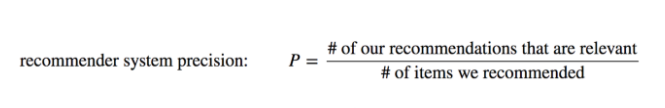

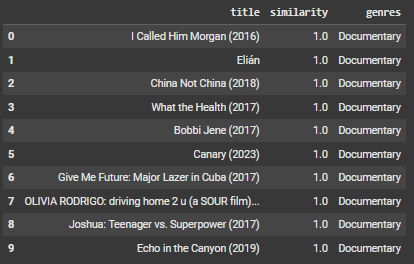

Dari gambar di atas dapat dilihat output top 10 film yang mirip dengan film yang dicari, yaitu Tokyo Girls (2000). Genre yang dimiliki oleh 10 film tersebut sama seperti film yang dicari. Oleh karena itu dengan menggunakan rumus presisi:
didapat perhitungan <br>
$Precision = \frac{10}{10} = 1.0$<br>
Jadi, precision yang dihasilkan oleh metode ini adalah sebesar 100% yang menandakan bahwa model ini memberikan rekomendasi film dengan sangat tepat.

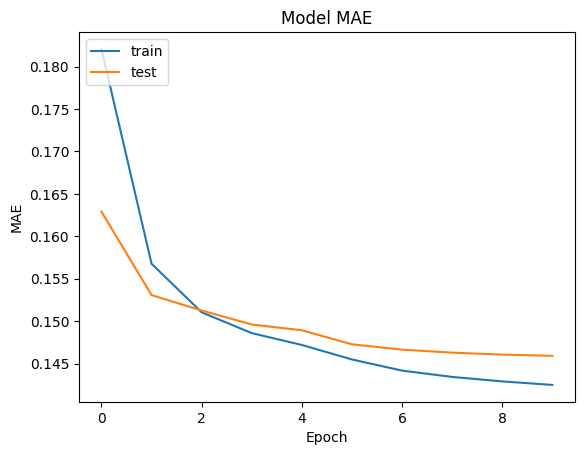

In [117]:
plt.plot(history.history['mean_absolute_error'])
plt.plot(history.history['val_mean_absolute_error'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Dari gambar di atas, dapat dilihat bahwa MAE train dan test sama-sama menurun yang menandakan bahwa model belajar dengan baik dan bagus. Tidak ada tanda-tanda bahwa model mengalami overfitting juga.

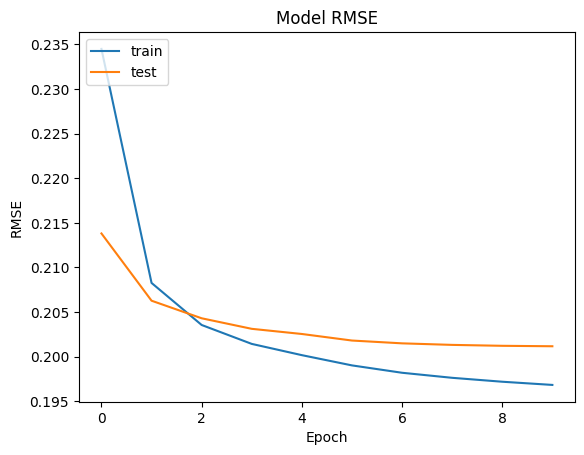

In [118]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('Model RMSE')
plt.ylabel('RMSE')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Dari gambar di atas, dapat dilihat bahwa RMSE train dan test menurun yang menandakan bahwa model berhasil mengurangi kesalahan prediksi. RMSE juga tidak terlihat meningkat sehingga model ini tidak mengalami overfitting.

## Kesimpulan

Kesimpulannya, dari kedua model yang sudah dibuat, model content-based filtering berhasil memberikan rekomendasi yang relevan berdasarkan kemiripan genre film dan model collaborative-based filtering berhasil memberikan rekomendasi yang lebih personal berdasarkan pola perilaku pengguna. Kedua model ini memiliki kelebihan masing-masing tergantung pada ketersediaan data. Jika metadata film tersedia tetapi histori pengguna tidak ada, maka content-based filtering merupakan solusi yang tepat. Begitu juga sebaliknya, apabila data rating pengguna tersedia, collaborative rating mampu memberikan rekomendasi yang lebih akurat dan personal.